In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from IQAEBinom_OnlyFinalRound import IQAEBinom_OnlyFinalRound

In [2]:
pTrue = 0.2
nGrover = 100
nShot = 100

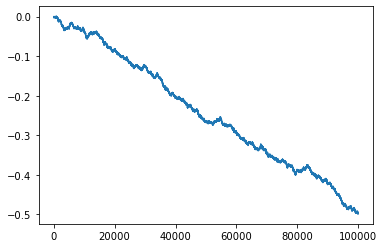

In [3]:
nEstim = 100000
estims = np.array([])
p1ObsFinals = np.array([])
for _ in range(nEstim):
    estim, p1ObsFinal = IQAEBinom_OnlyFinalRound(pTrue, nGrover, nShot)
    estims = np.append(estims, estim)
    p1ObsFinals = np.append(p1ObsFinals, p1ObsFinal)

errors = estims - pTrue
ax = plt.gca()
plt.plot(errors.cumsum())
plt.show()

In [4]:
# bias見積り
np.mean(errors)

-4.963638683682018e-06

In [18]:
# bias見積りの統計誤差
np.sqrt(np.var(errors) / nEstim)

6.340263513209247e-07

In [4]:
from BiasCorrection import BiasCordeiroKlein, BiasTaylorExpTo2nd, BiasTaylorExpTo3rd, BiasTaylorExpTo4th

In [6]:
# Cordeiro-Kleinのbias理論式　→　合わず...
BiasCordeiroKlein(pTrue, nGrover, nShot)

-2.384697028700929e-05

テイラー近似によるバイアス理論式は2シグマ以内で合ってる

In [7]:
BiasTaylorExpTo2nd(pTrue, nGrover, nShot)

-5.90605088095259e-06

In [8]:
BiasTaylorExpTo3rd(pTrue, nGrover, nShot)

-5.826542542985285e-06

In [15]:
nEstim = 1000000
nShot = 50
nGrovers = np.arange(100, 500, 1)
avgErrors = np.array([])
errStDevs = np.array([])
biasTaylor = np.array([])
for nG in nGrovers:
    errs = IQAEBinom_OnlyFinalRound(pTrue, nG, nShot, nEstim=nEstim) - pTrue
    avgErrors = np.append(avgErrors, np.mean(errs))
    errStDevs = np.append(errStDevs, np.std(errs) / np.sqrt(nEstim))
    biasTaylor = np.append(biasTaylor, BiasTaylorExpTo4th(pTrue, nG, nShot))

In [16]:
pd.options.display.float_format = '{:.4e}'.format
pd.set_option('display.max_rows', 100)
dfErrorBias = pd.DataFrame({"nGrover": nGrovers, "avgError": avgErrors, "errorStd": errStDevs, "bias": biasTaylor})
dfErrorBias["(avgErr-bias)/errorStd"] = (dfErrorBias["avgError"] - dfErrorBias["bias"]) / dfErrorBias["errorStd"]
dfErrorBias["p1Final"] = np.sin((2 * dfErrorBias["nGrover"] + 1) * np.arcsin(np.sqrt(pTrue))) ** 2
print(dfErrorBias)

     nGrover    avgError   errorStd        bias  (avgErr-bias)/errorStd  \
0        100 -1.2805e-05 2.8594e-07 -1.2331e-05             -1.6551e+00   
1        101  1.3575e-04 3.4532e-07  1.5053e-04             -4.2777e+01   
2        102  6.7745e-07 2.7899e-07  6.5972e-07              6.3575e-02   
3        103 -1.0965e-04 3.5107e-07 -9.2431e-05             -4.9043e+01   
4        104  1.4260e-05 2.7600e-07  1.3694e-05              2.0508e+00   
..       ...         ...        ...         ...                     ...   
395      495  6.9095e-08 5.7695e-08  1.4346e-07             -1.2890e+00   
396      496 -2.2623e-05 7.3296e-08 -1.8732e-05             -5.3092e+01   
397      497  2.9921e-06 5.7855e-08  2.8937e-06              1.7003e+00   
398      498 -3.5078e-06 5.8106e-08 -3.4615e-06             -7.9719e-01   
399      499  1.5822e-05 7.0667e-08  1.2129e-05              5.2262e+01   

       p1Final  
0   7.5639e-01  
1   1.6122e-02  
2   5.1458e-01  
3   9.7571e-01  
4   2.1902e-01

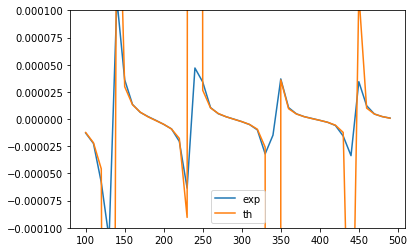

In [20]:
ax = plt.gca()
plt.plot(nGrovers[0::10], avgErrors[0::10], label="exp")
plt.plot(nGrovers[0::10], biasTaylor[0::10], label="th")
ax.set_ylim(-1e-4, 1e-4)
ax.legend()
plt.show()

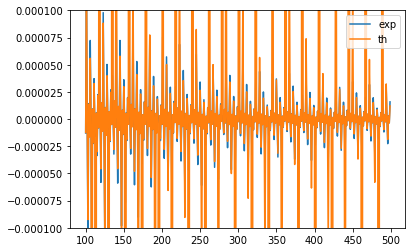

In [17]:
ax = plt.gca()
plt.plot(nGrovers, avgErrors, label="exp")
plt.plot(nGrovers, biasTaylor, label="th")
ax.set_ylim(-1e-4, 1e-4)
ax.legend()
plt.show()

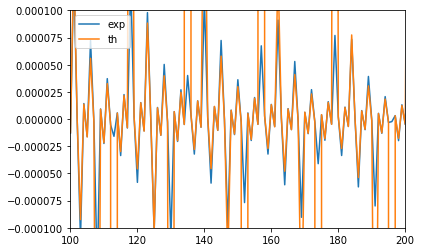

In [19]:
ax = plt.gca()
plt.plot(nGrovers, avgErrors, label="exp")
plt.plot(nGrovers, biasTaylor, label="th")
ax.set_xlim(100, 200)
ax.set_ylim(-1e-4, 1e-4)
ax.legend()
plt.show()

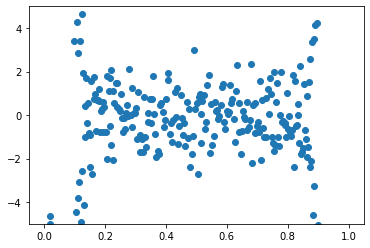

In [18]:
ax = plt.gca()
ax.set_ylim(-5,5)
plt.scatter(dfErrorBias["p1Final"], dfErrorBias["(avgErr-bias)/errorStd"])